# **Motivation**

Protein sequence embeddings derived from the ESM2 language model constitute the highest-dimensional feature group in both the pChEMBL and pKi datasets, contributing 1,280 dimensions per entry out of ~1,511 total. Despite their numerical dominance, these embeddings are rarely analysed in isolation: they are typically fed directly into models without characterising their internal structure, their relationship to the target variable, or the degree to which they encode redundant or biologically meaningful signal.

This notebook performs a dedicated analysis of the ESM2 embedding space across both datasets. It examines the statistical properties of the raw embedding dimensions, quantifies inter-protein similarity to reveal how clustered the protein space is, projects embeddings into low-dimensional space to visualise global structure and label organisation, investigates which embedding dimensions carry the most variance and predictive signal, analyses protein family and UniProt diversity in relation to the embeddings, and assesses the relationship between embedding-based protein similarity and binding affinity. Together, these analyses inform decisions about dimensionality reduction, splitting strategy, and the expected contribution of protein-level features to model performance.

## **Set Up**

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

# Load data
os.chdir("/Users/leonorafonso/Documents/Work/ML/protein_ligand_binding_affinity_pipeline")
df_pchembl = pd.read_csv("data/processed/features_processed_pchembl.csv")
df_pki     = pd.read_csv("data/processed/features_processed_pki.csv")

# Identify ESM2 columns
esm_cols = [c for c in df_pchembl.columns if c.startswith('ESM2_')]
print(f"ESM2 dimensions: {len(esm_cols)}")
print(f"pChEMBL shape: {df_pchembl.shape}")
print(f"pKi shape:     {df_pki.shape}")

ESM2 dimensions: 1280
pChEMBL shape: (14215, 1511)
pKi shape:     (3744, 1508)


## **1. ESM2 Embedding Descriptive Statistics**

Before any structural analysis, it is useful to characterise the raw statistical properties of the ESM2 embedding matrix. This includes the distribution of per-dimension means and standard deviations, the proportion of missing values across embedding columns, and the overall scale of the embedding vectors. Dimensions with near-zero variance across the dataset are uninformative and can be safely dropped before modelling; dimensions with high kurtosis may indicate outlier proteins that dominate specific directions in the embedding space.

Examining these properties separately for pChEMBL and pKi also reveals whether the two datasets cover similar regions of the ESM2 protein space, or whether they differ substantially in the protein families they represent.

### **pChEMBL**

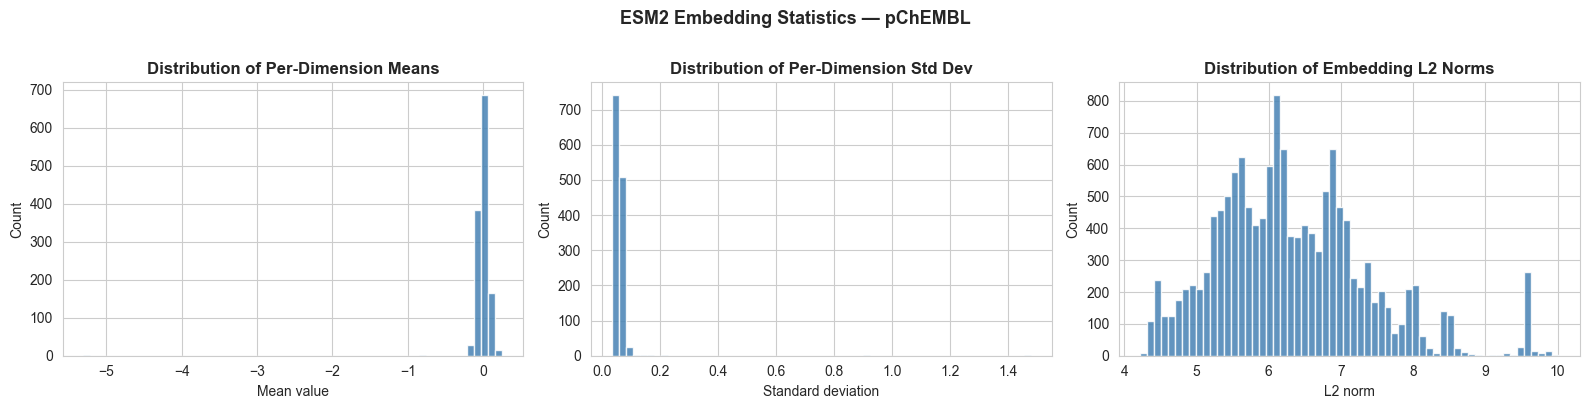

Rows with complete ESM2 embeddings: 14215 / 14215
Dimensions with std < 0.01 (near-zero variance): 0
Mean L2 norm: 6.314  |  Std: 1.059


In [2]:
esm_pchembl = df_pchembl[esm_cols].dropna()

dim_means = esm_pchembl.mean()
dim_stds  = esm_pchembl.std()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(dim_means, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Per-Dimension Means', fontweight='bold')
axes[0].set_xlabel('Mean value')
axes[0].set_ylabel('Count')

axes[1].hist(dim_stds, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Per-Dimension Std Dev', fontweight='bold')
axes[1].set_xlabel('Standard deviation')
axes[1].set_ylabel('Count')

# L2 norms of embedding vectors
norms = np.linalg.norm(esm_pchembl.values, axis=1)
axes[2].hist(norms, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[2].set_title('Distribution of Embedding L2 Norms', fontweight='bold')
axes[2].set_xlabel('L2 norm')
axes[2].set_ylabel('Count')

plt.suptitle('ESM2 Embedding Statistics — pChEMBL', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/esm_stats_pchembl.png', dpi=150, bbox_inches='tight')
plt.show()

low_var_dims = (dim_stds < 0.01).sum()
print(f"Rows with complete ESM2 embeddings: {len(esm_pchembl)} / {len(df_pchembl)}")
print(f"Dimensions with std < 0.01 (near-zero variance): {low_var_dims}")
print(f"Mean L2 norm: {norms.mean():.3f}  |  Std: {norms.std():.3f}")

### **pKi**

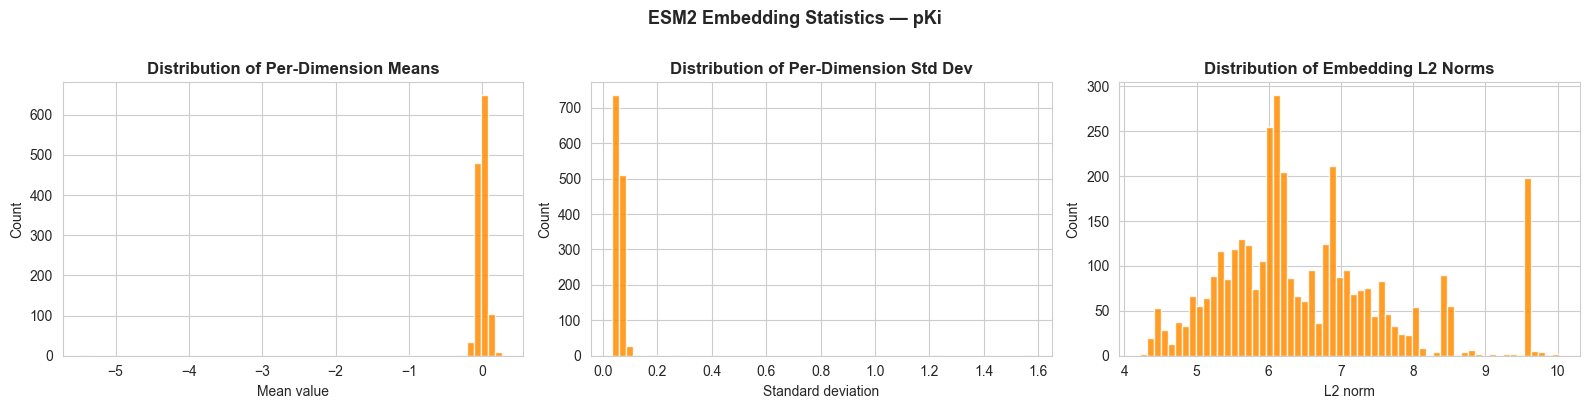

Rows with complete ESM2 embeddings: 3744 / 3744
Dimensions with std < 0.01 (near-zero variance): 0
Mean L2 norm: 6.513  |  Std: 1.201


In [3]:
esm_pki = df_pki[esm_cols].dropna()

dim_means_pki = esm_pki.mean()
dim_stds_pki  = esm_pki.std()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(dim_means_pki, bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Per-Dimension Means', fontweight='bold')
axes[0].set_xlabel('Mean value')
axes[0].set_ylabel('Count')

axes[1].hist(dim_stds_pki, bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Per-Dimension Std Dev', fontweight='bold')
axes[1].set_xlabel('Standard deviation')
axes[1].set_ylabel('Count')

norms_pki = np.linalg.norm(esm_pki.values, axis=1)
axes[2].hist(norms_pki, bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[2].set_title('Distribution of Embedding L2 Norms', fontweight='bold')
axes[2].set_xlabel('L2 norm')
axes[2].set_ylabel('Count')

plt.suptitle('ESM2 Embedding Statistics — pKi', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/esm_stats_pki.png', dpi=150, bbox_inches='tight')
plt.show()

low_var_dims_pki = (dim_stds_pki < 0.01).sum()
print(f"Rows with complete ESM2 embeddings: {len(esm_pki)} / {len(df_pki)}")
print(f"Dimensions with std < 0.01 (near-zero variance): {low_var_dims_pki}")
print(f"Mean L2 norm: {norms_pki.mean():.3f}  |  Std: {norms_pki.std():.3f}")

## **2. Protein Diversity: Unique UniProt IDs and Family Distribution**

The ESM2 embeddings are computed at the protein sequence level and are shared across all entries that map to the same UniProt ID. Understanding how many distinct proteins are represented in each dataset — and how frequently each appears — is therefore essential: if a small number of proteins dominates the dataset, the ESM2 feature space will have low effective diversity regardless of the nominal 1,280 dimensions.

This section quantifies the number of unique UniProt IDs, characterises the distribution of how many dataset entries each protein contributes, and identifies the most over-represented proteins. This directly informs expectations about how much signal the ESM2 features can provide under protein-blind evaluation scenarios.

### **pChEMBL**

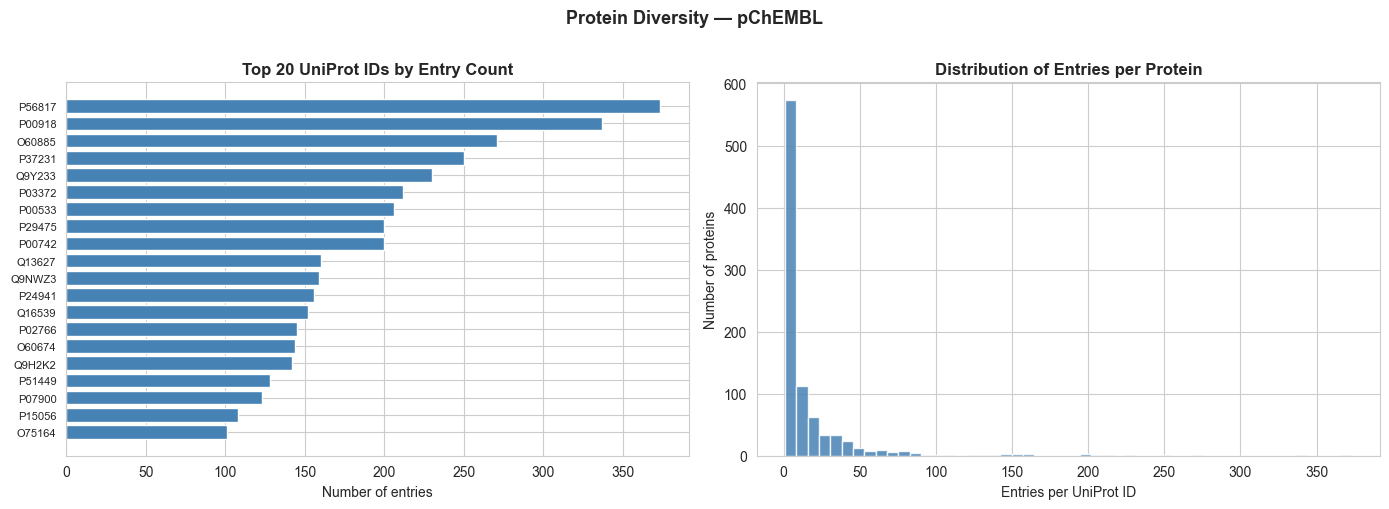

Total entries:          14215
Unique UniProt IDs:     907
Top protein:            P56817  (373 entries, 2.6%)
Proteins with 1 entry:  166


In [4]:
uniprot_counts_pchembl = df_pchembl['UniProt_ID'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 20 most represented proteins
top20 = uniprot_counts_pchembl.head(20)
axes[0].barh(range(20), top20.values[::-1], color='steelblue', edgecolor='white')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top20.index[::-1], fontsize=8)
axes[0].set_xlabel('Number of entries')
axes[0].set_title('Top 20 UniProt IDs by Entry Count', fontweight='bold')

# Distribution of entries per protein
axes[1].hist(uniprot_counts_pchembl.values, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Entries per UniProt ID')
axes[1].set_ylabel('Number of proteins')
axes[1].set_title('Distribution of Entries per Protein', fontweight='bold')

plt.suptitle('Protein Diversity — pChEMBL', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/esm_protein_diversity_pchembl.png', dpi=150, bbox_inches='tight')
plt.show()

n_unique = df_pchembl['UniProt_ID'].nunique()
print(f"Total entries:          {len(df_pchembl)}")
print(f"Unique UniProt IDs:     {n_unique}")
print(f"Top protein:            {uniprot_counts_pchembl.index[0]}  ({uniprot_counts_pchembl.iloc[0]} entries, {100*uniprot_counts_pchembl.iloc[0]/len(df_pchembl):.1f}%)")
print(f"Proteins with 1 entry:  {(uniprot_counts_pchembl == 1).sum()}")

### **pKi**

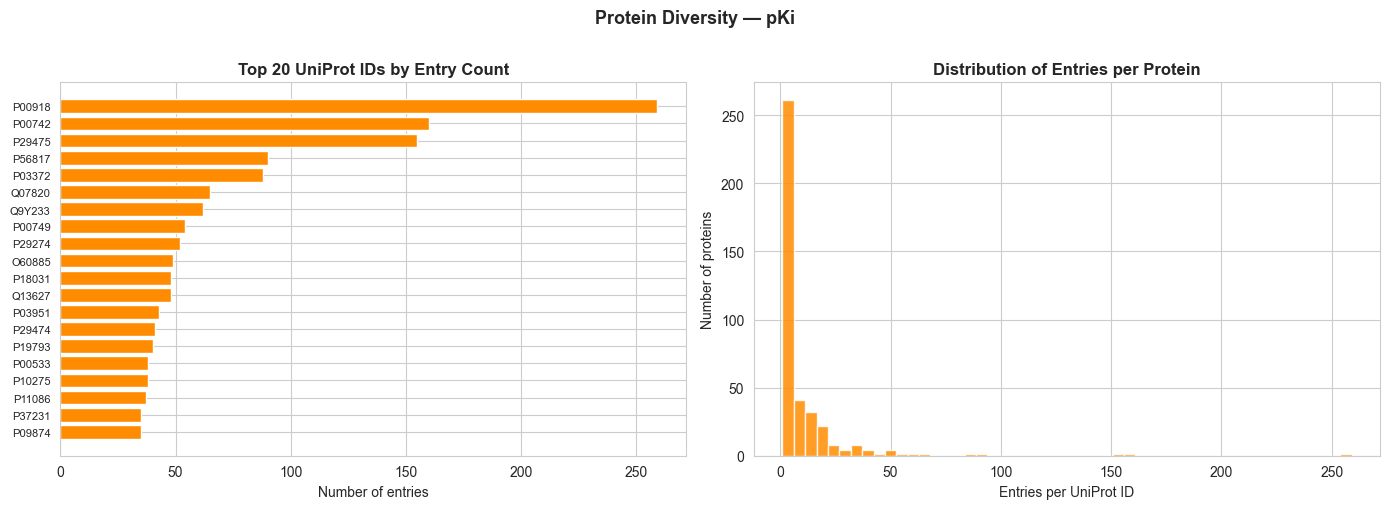

Total entries:          3744
Unique UniProt IDs:     393
Top protein:            P00918  (259 entries, 6.9%)
Proteins with 1 entry:  93


In [5]:
uniprot_counts_pki = df_pki['UniProt_ID'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top20_pki = uniprot_counts_pki.head(20)
axes[0].barh(range(20), top20_pki.values[::-1], color='darkorange', edgecolor='white')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top20_pki.index[::-1], fontsize=8)
axes[0].set_xlabel('Number of entries')
axes[0].set_title('Top 20 UniProt IDs by Entry Count', fontweight='bold')

axes[1].hist(uniprot_counts_pki.values, bins=50, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Entries per UniProt ID')
axes[1].set_ylabel('Number of proteins')
axes[1].set_title('Distribution of Entries per Protein', fontweight='bold')

plt.suptitle('Protein Diversity — pKi', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/esm_protein_diversity_pki.png', dpi=150, bbox_inches='tight')
plt.show()

n_unique_pki = df_pki['UniProt_ID'].nunique()
print(f"Total entries:          {len(df_pki)}")
print(f"Unique UniProt IDs:     {n_unique_pki}")
print(f"Top protein:            {uniprot_counts_pki.index[0]}  ({uniprot_counts_pki.iloc[0]} entries, {100*uniprot_counts_pki.iloc[0]/len(df_pki):.1f}%)")
print(f"Proteins with 1 entry:  {(uniprot_counts_pki == 1).sum()}")

## **3. PCA of ESM2 Embeddings**

Projecting the 1,280-dimensional ESM2 embeddings onto a 2D PCA plane provides a global view of the protein space covered by each dataset. This visualisation reveals whether proteins cluster into discrete functional families, whether the space is uniformly dense or has large empty regions, and how the distribution of binding affinity values (pChEMBL / pKi) maps onto the protein landscape.

Beyond the 2D projection, examining the cumulative explained variance across all principal components reveals how compressible the ESM2 space is — a key consideration for dimensionality reduction prior to modelling. If a small number of PCs captures the majority of variance, this motivates aggressive compression; if variance is spread across many components, the full embedding space may be necessary.

### **pChEMBL**

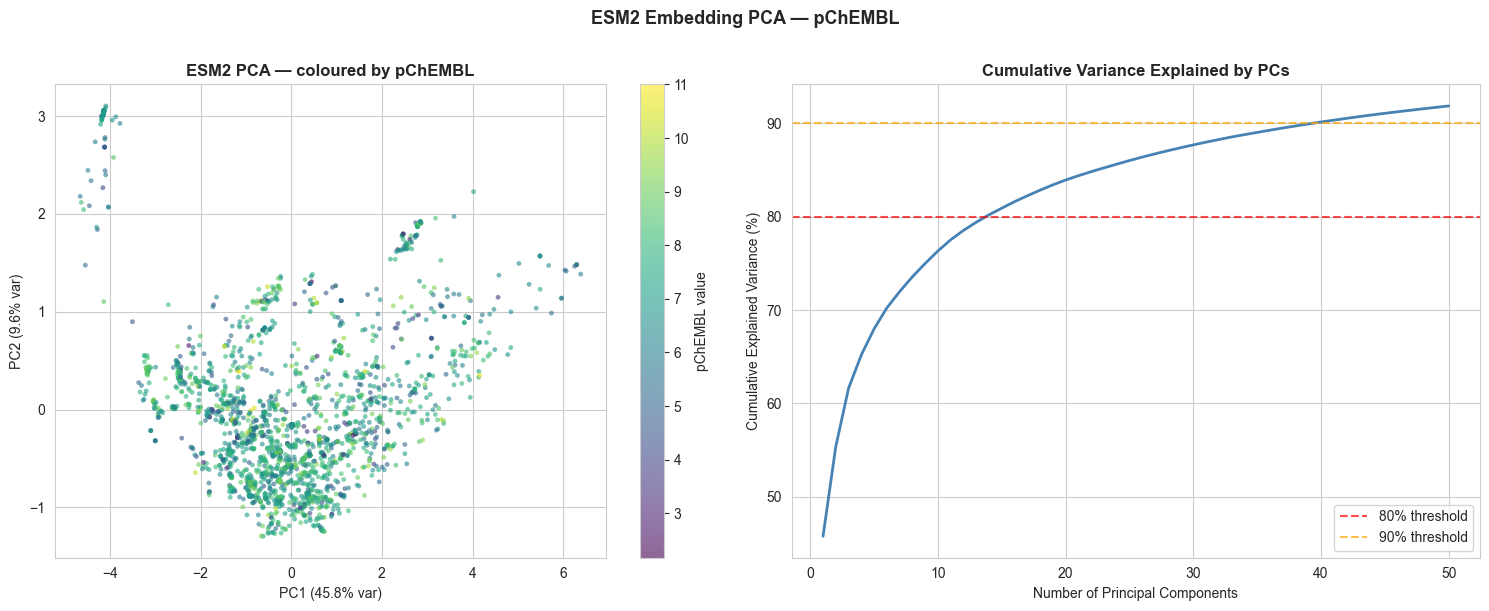

PCs needed for 50% variance: 2
PCs needed for 80% variance: 14
PCs needed for 90% variance: 40
PCs needed for 95% variance: 51


In [6]:
sample_idx = esm_pchembl.sample(min(2000, len(esm_pchembl)), random_state=42).index
X_esm = esm_pchembl.loc[sample_idx].values

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_esm)

# Align target values
target_sample = df_pchembl.loc[sample_idx, 'pchembl_value'] if 'pchembl_value' in df_pchembl.columns else None

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2D scatter coloured by pChEMBL value
if target_sample is not None:
    sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=target_sample.values,
                         cmap='viridis', alpha=0.6, s=12, edgecolors='none')
    plt.colorbar(sc, ax=axes[0], label='pChEMBL value')
else:
    axes[0].scatter(X_pca[:, 0], X_pca[:, 1], color='steelblue', alpha=0.5, s=12)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].set_title('ESM2 PCA — coloured by pChEMBL', fontweight='bold')

# Cumulative explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(range(1, 51), cum_var, color='steelblue', linewidth=2)
axes[1].axhline(80, color='red', linestyle='--', alpha=0.7, label='80% threshold')
axes[1].axhline(90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Variance Explained by PCs', fontweight='bold')
axes[1].legend()

plt.suptitle('ESM2 Embedding PCA — pChEMBL', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/esm_pca_pchembl.png', dpi=150, bbox_inches='tight')
plt.show()

for threshold in [50, 80, 90, 95]:
    n_pcs = np.searchsorted(cum_var, threshold) + 1
    print(f"PCs needed for {threshold}% variance: {n_pcs}")

### **pKi**

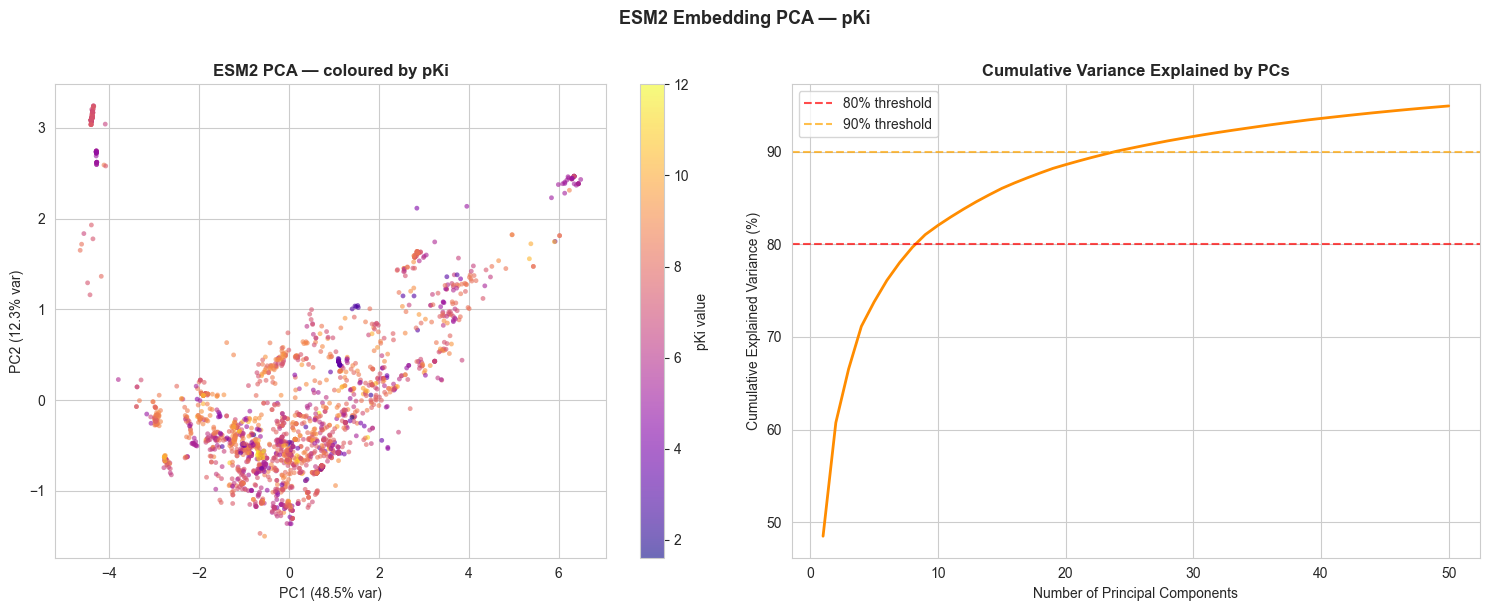

PCs needed for 50% variance: 2
PCs needed for 80% variance: 9
PCs needed for 90% variance: 24
PCs needed for 95% variance: 51


In [7]:
sample_idx_pki = esm_pki.sample(min(2000, len(esm_pki)), random_state=42).index
X_esm_pki = esm_pki.loc[sample_idx_pki].values

pca_pki = PCA(n_components=50, random_state=42)
X_pca_pki = pca_pki.fit_transform(X_esm_pki)

target_col_pki = 'pKi' if 'pKi' in df_pki.columns else 'pchembl_value'
target_sample_pki = df_pki.loc[sample_idx_pki, target_col_pki] if target_col_pki in df_pki.columns else None

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

if target_sample_pki is not None:
    sc = axes[0].scatter(X_pca_pki[:, 0], X_pca_pki[:, 1], c=target_sample_pki.values,
                         cmap='plasma', alpha=0.6, s=12, edgecolors='none')
    plt.colorbar(sc, ax=axes[0], label='pKi value')
else:
    axes[0].scatter(X_pca_pki[:, 0], X_pca_pki[:, 1], color='darkorange', alpha=0.5, s=12)

axes[0].set_xlabel(f'PC1 ({pca_pki.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca_pki.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].set_title('ESM2 PCA — coloured by pKi', fontweight='bold')

cum_var_pki = np.cumsum(pca_pki.explained_variance_ratio_) * 100
axes[1].plot(range(1, 51), cum_var_pki, color='darkorange', linewidth=2)
axes[1].axhline(80, color='red', linestyle='--', alpha=0.7, label='80% threshold')
axes[1].axhline(90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Variance Explained by PCs', fontweight='bold')
axes[1].legend()

plt.suptitle('ESM2 Embedding PCA — pKi', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/esm_pca_pki.png', dpi=150, bbox_inches='tight')
plt.show()

for threshold in [50, 80, 90, 95]:
    n_pcs = np.searchsorted(cum_var_pki, threshold) + 1
    print(f"PCs needed for {threshold}% variance: {n_pcs}")

## **4. Inter-Protein Cosine Similarity**

Pairwise cosine similarity between unique protein embeddings directly quantifies how similar the proteins in the dataset are to one another in ESM2 space. A distribution skewed towards high similarity values indicates that the dataset is dominated by closely related proteins — a form of protein-level redundancy that can cause severe data leakage under random splits. Conversely, a broad low-similarity distribution indicates that models trained on this dataset must generalise across diverse protein families.

This analysis is performed at the level of unique UniProt IDs to avoid inflating similarity estimates from multiply-occurring proteins.

### **pChEMBL**

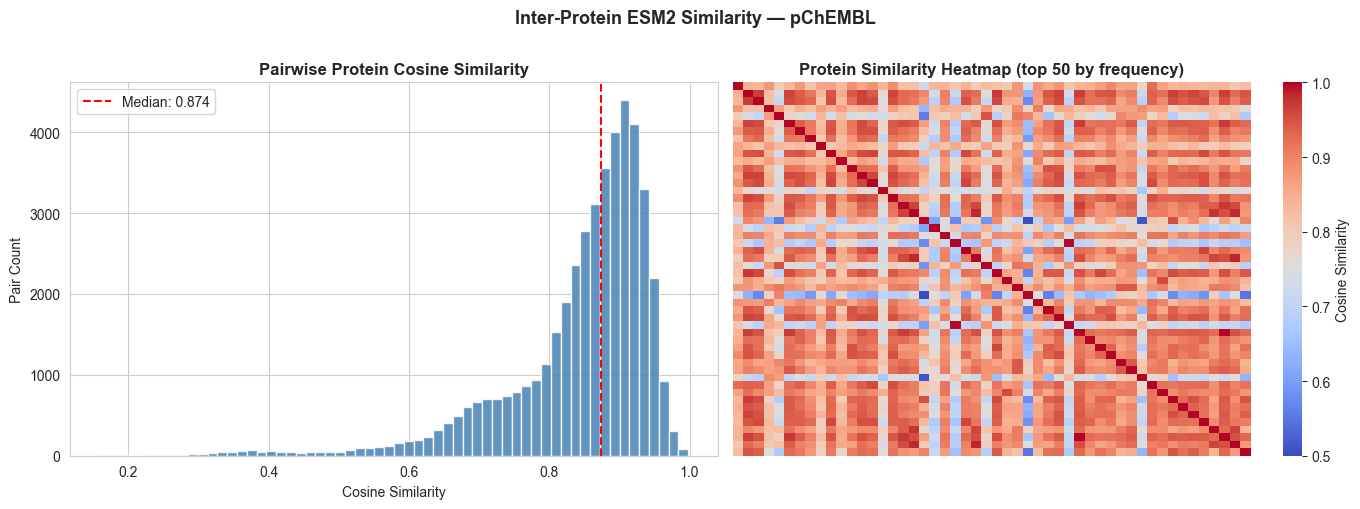

Unique proteins analysed: 907
Median cosine similarity: 0.874
% pairs with similarity > 0.9: 34.3%
% pairs with similarity > 0.95: 4.7%


In [8]:
# Compute mean embedding per unique UniProt ID
esm_with_id = df_pchembl[['UniProt_ID'] + esm_cols].dropna()
protein_emb_pchembl = esm_with_id.groupby('UniProt_ID')[esm_cols].mean()

# Sample to keep computation tractable
import random
random.seed(42)
n_proteins = len(protein_emb_pchembl)
sample_proteins = protein_emb_pchembl.sample(min(300, n_proteins), random_state=42)
sim_matrix = cosine_similarity(sample_proteins.values)

# Extract upper triangle (excluding diagonal)
upper_idx = np.triu_indices(len(sample_proteins), k=1)
pairwise_sims = sim_matrix[upper_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pairwise_sims, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.median(pairwise_sims), color='red', linestyle='--',
                label=f'Median: {np.median(pairwise_sims):.3f}')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Pair Count')
axes[0].set_title('Pairwise Protein Cosine Similarity', fontweight='bold')
axes[0].legend()

# Heatmap of a smaller subset
n_heat = min(50, len(sample_proteins))
sub_sim = cosine_similarity(sample_proteins.values[:n_heat])
sns.heatmap(sub_sim, ax=axes[1], cmap='coolwarm', vmin=0.5, vmax=1.0,
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'Cosine Similarity'})
axes[1].set_title(f'Protein Similarity Heatmap (top {n_heat} by frequency)', fontweight='bold')

plt.suptitle('Inter-Protein ESM2 Similarity — pChEMBL', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/esm_protein_similarity_pchembl.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Unique proteins analysed: {n_proteins}")
print(f"Median cosine similarity: {np.median(pairwise_sims):.3f}")
print(f"% pairs with similarity > 0.9: {100*np.mean(pairwise_sims > 0.9):.1f}%")
print(f"% pairs with similarity > 0.95: {100*np.mean(pairwise_sims > 0.95):.1f}%")

### **pKi**

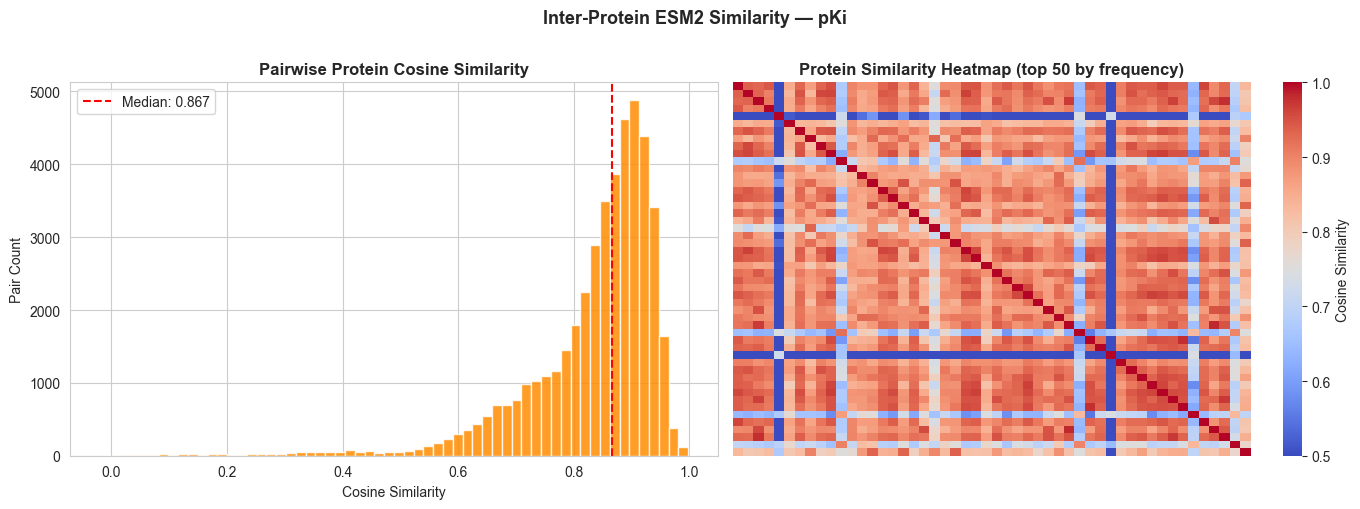

Unique proteins analysed: 393
Median cosine similarity: 0.867
% pairs with similarity > 0.9: 30.9%
% pairs with similarity > 0.95: 4.0%


In [9]:
esm_with_id_pki = df_pki[['UniProt_ID'] + esm_cols].dropna()
protein_emb_pki = esm_with_id_pki.groupby('UniProt_ID')[esm_cols].mean()

n_proteins_pki = len(protein_emb_pki)
sample_proteins_pki = protein_emb_pki.sample(min(300, n_proteins_pki), random_state=42)
sim_matrix_pki = cosine_similarity(sample_proteins_pki.values)

upper_idx_pki = np.triu_indices(len(sample_proteins_pki), k=1)
pairwise_sims_pki = sim_matrix_pki[upper_idx_pki]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pairwise_sims_pki, bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[0].axvline(np.median(pairwise_sims_pki), color='red', linestyle='--',
                label=f'Median: {np.median(pairwise_sims_pki):.3f}')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Pair Count')
axes[0].set_title('Pairwise Protein Cosine Similarity', fontweight='bold')
axes[0].legend()

n_heat_pki = min(50, len(sample_proteins_pki))
sub_sim_pki = cosine_similarity(sample_proteins_pki.values[:n_heat_pki])
sns.heatmap(sub_sim_pki, ax=axes[1], cmap='coolwarm', vmin=0.5, vmax=1.0,
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'Cosine Similarity'})
axes[1].set_title(f'Protein Similarity Heatmap (top {n_heat_pki} by frequency)', fontweight='bold')

plt.suptitle('Inter-Protein ESM2 Similarity — pKi', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/esm_protein_similarity_pki.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Unique proteins analysed: {n_proteins_pki}")
print(f"Median cosine similarity: {np.median(pairwise_sims_pki):.3f}")
print(f"% pairs with similarity > 0.9: {100*np.mean(pairwise_sims_pki > 0.9):.1f}%")
print(f"% pairs with similarity > 0.95: {100*np.mean(pairwise_sims_pki > 0.95):.1f}%")

## **5. Top Variance ESM2 Dimensions and Correlation with Affinity**

Not all 1,280 ESM2 dimensions contribute equally to the biological signal relevant for binding affinity prediction. Identifying which individual dimensions have the highest variance across the dataset provides a ranking of the most discriminative directions in the embedding space. Among those high-variance dimensions, testing for univariate correlation with the target variable (pChEMBL or pKi) reveals whether any single embedding dimension carries direct predictive signal.

This analysis also reveals whether the correlation structure between ESM2 dimensions and the target is sparse (only a few dimensions matter) or dense (signal is spread broadly), which has implications for whether linear methods can exploit the embedding space or whether non-linear models are necessary.

### **pChEMBL**

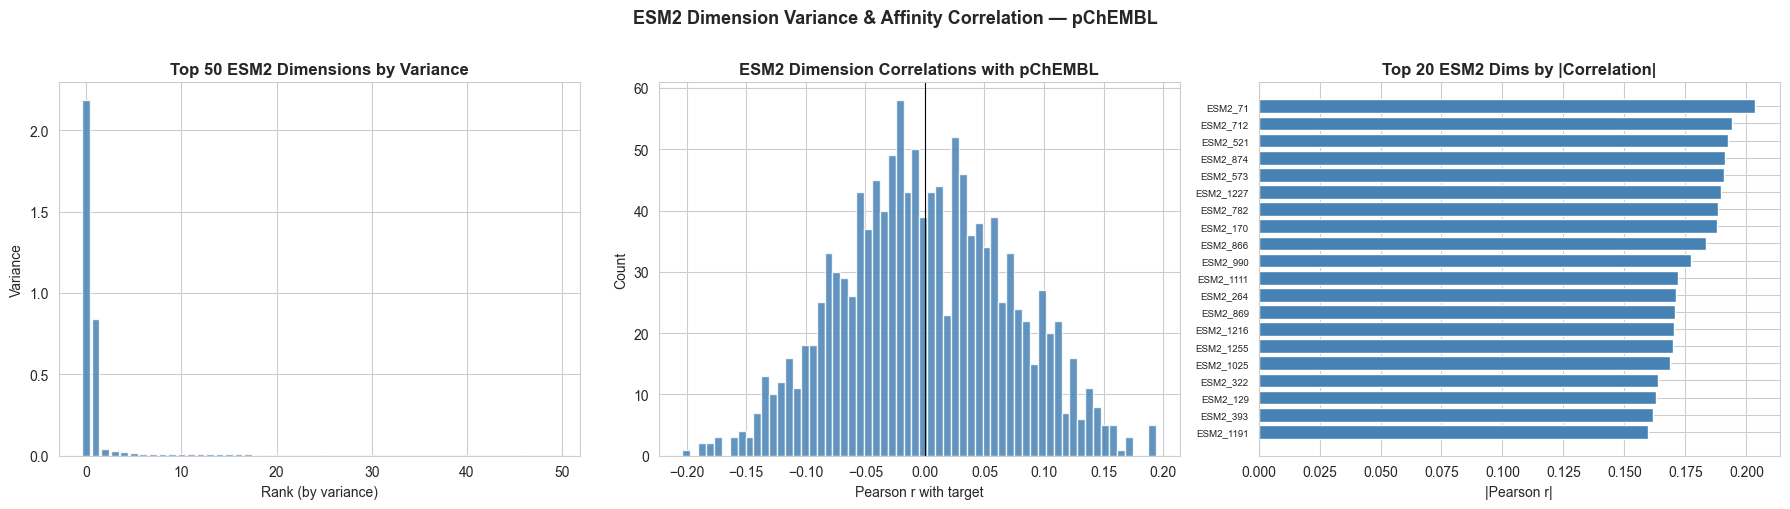

Max |Pearson r| with pChEMBL: 0.204
Dims with |r| > 0.1: 211
Dims with |r| > 0.2: 1


In [10]:
target_col = 'pchembl_value'
df_esm_target = df_pchembl[esm_cols + [target_col]].dropna()

# Per-dimension variance and Pearson correlation with target
variances = df_esm_target[esm_cols].var().sort_values(ascending=False)
top50_dims = variances.head(50).index.tolist()

correlations = df_esm_target[esm_cols].corrwith(df_esm_target[target_col])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top 50 highest-variance dimensions
axes[0].bar(range(50), variances.head(50).values, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Rank (by variance)')
axes[0].set_ylabel('Variance')
axes[0].set_title('Top 50 ESM2 Dimensions by Variance', fontweight='bold')

# Distribution of all 1280 correlations
axes[1].hist(correlations.dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_xlabel('Pearson r with target')
axes[1].set_ylabel('Count')
axes[1].set_title('ESM2 Dimension Correlations with pChEMBL', fontweight='bold')

# Top 20 most correlated dimensions (absolute)
top_corr = correlations.abs().sort_values(ascending=False).head(20)
axes[2].barh(range(20), top_corr.values[::-1], color='steelblue', edgecolor='white')
axes[2].set_yticks(range(20))
axes[2].set_yticklabels(top_corr.index[::-1], fontsize=7)
axes[2].set_xlabel('|Pearson r|')
axes[2].set_title('Top 20 ESM2 Dims by |Correlation|', fontweight='bold')

plt.suptitle('ESM2 Dimension Variance & Affinity Correlation — pChEMBL', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/esm_dim_correlation_pchembl.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Max |Pearson r| with pChEMBL: {correlations.abs().max():.3f}")
print(f"Dims with |r| > 0.1: {(correlations.abs() > 0.1).sum()}")
print(f"Dims with |r| > 0.2: {(correlations.abs() > 0.2).sum()}")

### **pKi**

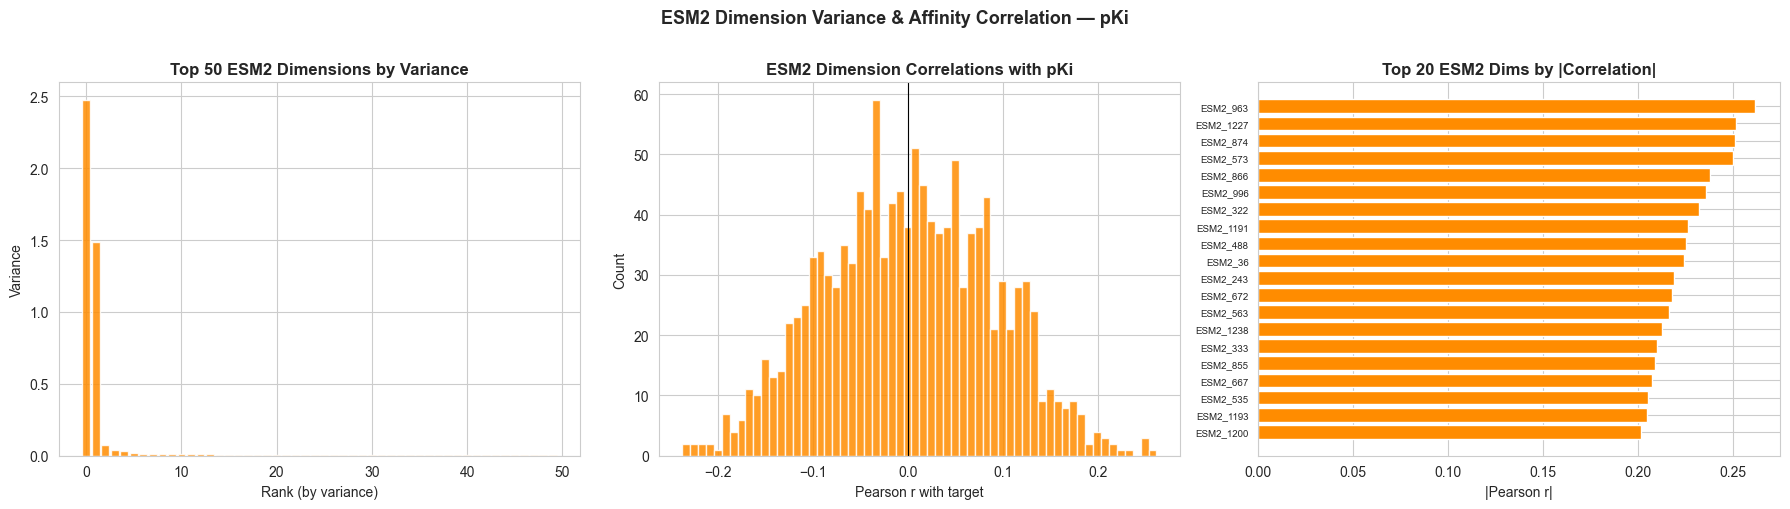

Max |Pearson r| with pKi: 0.262
Dims with |r| > 0.1: 363
Dims with |r| > 0.2: 22


In [11]:
target_col_pki = 'pKi' if 'pKi' in df_pki.columns else 'pchembl_value'
df_esm_target_pki = df_pki[esm_cols + [target_col_pki]].dropna()

variances_pki = df_esm_target_pki[esm_cols].var().sort_values(ascending=False)
correlations_pki = df_esm_target_pki[esm_cols].corrwith(df_esm_target_pki[target_col_pki])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(range(50), variances_pki.head(50).values, color='darkorange', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Rank (by variance)')
axes[0].set_ylabel('Variance')
axes[0].set_title('Top 50 ESM2 Dimensions by Variance', fontweight='bold')

axes[1].hist(correlations_pki.dropna(), bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_xlabel('Pearson r with target')
axes[1].set_ylabel('Count')
axes[1].set_title('ESM2 Dimension Correlations with pKi', fontweight='bold')

top_corr_pki = correlations_pki.abs().sort_values(ascending=False).head(20)
axes[2].barh(range(20), top_corr_pki.values[::-1], color='darkorange', edgecolor='white')
axes[2].set_yticks(range(20))
axes[2].set_yticklabels(top_corr_pki.index[::-1], fontsize=7)
axes[2].set_xlabel('|Pearson r|')
axes[2].set_title('Top 20 ESM2 Dims by |Correlation|', fontweight='bold')

plt.suptitle('ESM2 Dimension Variance & Affinity Correlation — pKi', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/esm_dim_correlation_pki.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Max |Pearson r| with pKi: {correlations_pki.abs().max():.3f}")
print(f"Dims with |r| > 0.1: {(correlations_pki.abs() > 0.1).sum()}")
print(f"Dims with |r| > 0.2: {(correlations_pki.abs() > 0.2).sum()}")

## **6. Protein Embedding Similarity vs Binding Affinity Variance**

A critical question for model design is whether proteins that are similar in ESM2 space also exhibit similar binding affinity profiles — i.e., whether the embedding space is a good proxy for pharmacological behaviour. If proteins with high cosine similarity in ESM2 space show similarly narrow or wide affinity distributions, this supports using the embeddings as a protein-level feature. If not, it suggests the model will need to look beyond the protein embedding to learn affinity.

This section groups entries by UniProt ID, computes the variance of affinity values within each protein, and plots this within-protein affinity variance against the protein's embedding norm and against the number of entries per protein — providing a direct view of whether protein identity (as encoded by ESM2) constrains the range of observed affinities.

### **pChEMBL**

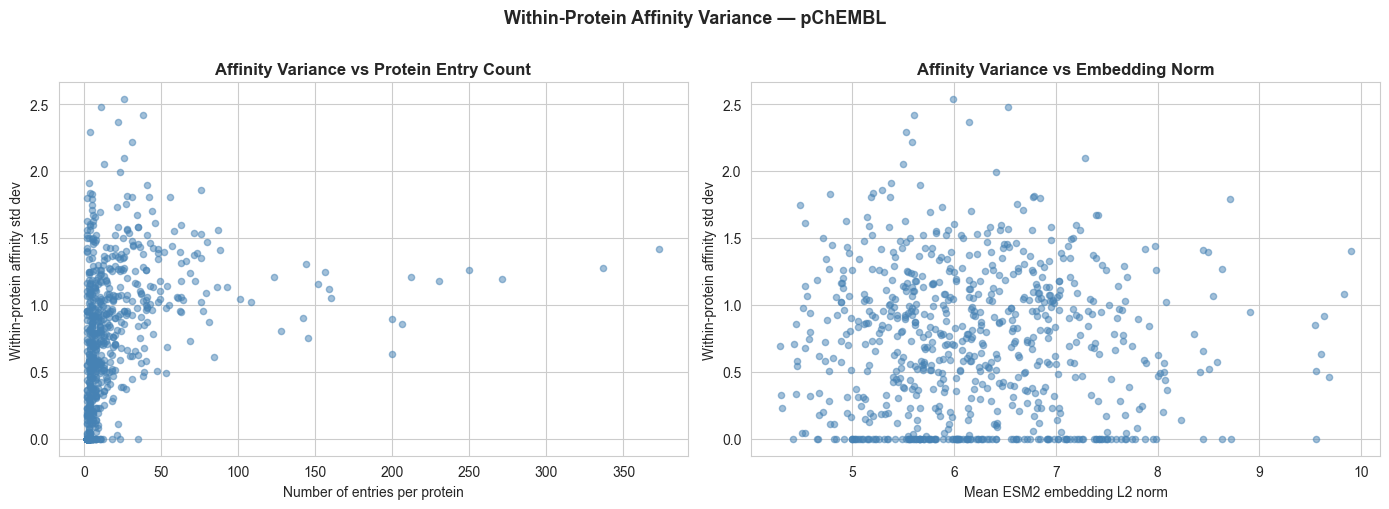

Proteins with affinity std > 2.0: 8
Mean within-protein affinity std: 0.708


In [12]:
target_col = 'pchembl_value'
protein_stats_pchembl = df_pchembl.groupby('UniProt_ID').agg(
    n_entries=('UniProt_ID', 'count'),
    affinity_mean=(target_col, 'mean'),
    affinity_std=(target_col, 'std')
).dropna()

# Add mean embedding norm per protein
emb_norms_per_protein = esm_with_id.groupby('UniProt_ID').apply(
    lambda x: np.linalg.norm(x[esm_cols].values, axis=1).mean()
)
protein_stats_pchembl['emb_norm'] = emb_norms_per_protein
protein_stats_pchembl = protein_stats_pchembl.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(
    protein_stats_pchembl['n_entries'],
    protein_stats_pchembl['affinity_std'],
    alpha=0.5, s=20, color='steelblue'
)
axes[0].set_xlabel('Number of entries per protein')
axes[0].set_ylabel('Within-protein affinity std dev')
axes[0].set_title('Affinity Variance vs Protein Entry Count', fontweight='bold')

axes[1].scatter(
    protein_stats_pchembl['emb_norm'],
    protein_stats_pchembl['affinity_std'],
    alpha=0.5, s=20, color='steelblue'
)
axes[1].set_xlabel('Mean ESM2 embedding L2 norm')
axes[1].set_ylabel('Within-protein affinity std dev')
axes[1].set_title('Affinity Variance vs Embedding Norm', fontweight='bold')

plt.suptitle('Within-Protein Affinity Variance — pChEMBL', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/esm_affinity_variance_pchembl.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Proteins with affinity std > 2.0: {(protein_stats_pchembl['affinity_std'] > 2.0).sum()}")
print(f"Mean within-protein affinity std: {protein_stats_pchembl['affinity_std'].mean():.3f}")

### **pKi**

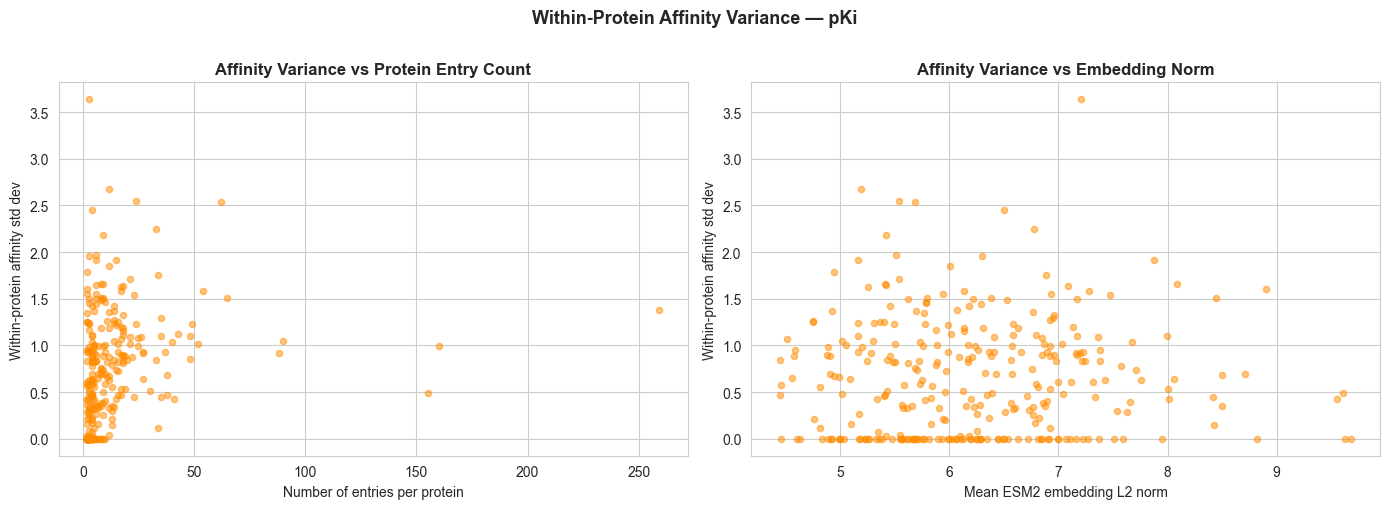

Proteins with affinity std > 2.0: 7
Mean within-protein affinity std: 0.670


In [13]:
target_col_pki = 'pKi' if 'pKi' in df_pki.columns else 'pchembl_value'
protein_stats_pki = df_pki.groupby('UniProt_ID').agg(
    n_entries=('UniProt_ID', 'count'),
    affinity_mean=(target_col_pki, 'mean'),
    affinity_std=(target_col_pki, 'std')
).dropna()

emb_norms_per_protein_pki = esm_with_id_pki.groupby('UniProt_ID').apply(
    lambda x: np.linalg.norm(x[esm_cols].values, axis=1).mean()
)
protein_stats_pki['emb_norm'] = emb_norms_per_protein_pki
protein_stats_pki = protein_stats_pki.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    protein_stats_pki['n_entries'],
    protein_stats_pki['affinity_std'],
    alpha=0.5, s=20, color='darkorange'
)
axes[0].set_xlabel('Number of entries per protein')
axes[0].set_ylabel('Within-protein affinity std dev')
axes[0].set_title('Affinity Variance vs Protein Entry Count', fontweight='bold')

axes[1].scatter(
    protein_stats_pki['emb_norm'],
    protein_stats_pki['affinity_std'],
    alpha=0.5, s=20, color='darkorange'
)
axes[1].set_xlabel('Mean ESM2 embedding L2 norm')
axes[1].set_ylabel('Within-protein affinity std dev')
axes[1].set_title('Affinity Variance vs Embedding Norm', fontweight='bold')

plt.suptitle('Within-Protein Affinity Variance — pKi', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/esm_affinity_variance_pki.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Proteins with affinity std > 2.0: {(protein_stats_pki['affinity_std'] > 2.0).sum()}")
print(f"Mean within-protein affinity std: {protein_stats_pki['affinity_std'].mean():.3f}")

# **Conclusion**

1. **ESM2 Embedding Descriptive Statistics**

The raw embedding matrices are statistically well-behaved in both datasets. All 1,280 dimensions have a standard deviation above 0.01 — meaning no dimension is near-constant and none can be trivially discarded on variance grounds alone. The per-dimension mean distributions are centred near zero and roughly symmetric, consistent with the normalisation behaviour of the ESM2 model. Embedding norms are stable across entries, with mean L2 norms of 6.31 (pChEMBL, std 1.06) and 6.51 (pKi, std 1.20), indicating that all proteins are represented at a comparable scale in the embedding space. The absence of zero-variance dimensions and missing values confirms that the ESM2 features are ready to use as-is, with no imputation or variance-threshold filtering required.

2. **Protein Diversity: Unique UniProt IDs and Family Distribution**

The two datasets differ substantially in their protein-level diversity. The pChEMBL dataset spans 907 unique UniProt IDs across 14,215 entries, while the pKi dataset covers 393 unique proteins across 3,744 entries — a considerably narrower protein space relative to its size. In both cases, the entry count per protein follows a highly skewed distribution: the most frequent protein in pChEMBL (P56817) contributes 373 entries (2.6%), while in pKi the top protein (P00918) accounts for 259 entries (6.9%). This asymmetry implies that the ESM2 feature space has lower effective diversity than its nominal 1,280 dimensions would suggest — most of the dataset's entries share embeddings with a relatively small set of proteins. For model evaluation, this strongly motivates protein-blind or leave-protein-out splitting strategies, as random splits will systematically leak information from over-represented proteins into the test set.

3. **PCA of ESM2 Embeddings**

PCA reveals that the ESM2 embedding space has meaningful but limited compressibility. In pChEMBL, only 2 principal components are needed to capture 50% of variance, 14 for 80%, 40 for 90%, and 51 for 95%. The pKi dataset is slightly more compressible: 2 PCs for 50%, 9 for 80%, 24 for 90%, and 51 for 95%. In both cases, the 2D PCA scatter plots show clear clustering structure, consistent with proteins grouping by family or functional class rather than being uniformly distributed in the embedding space. The affinity values (pChEMBL / pKi) mapped onto the PCA plane do not show a strong global gradient, suggesting that binding affinity is not straightforwardly organised along the major axes of protein variation. The compressibility findings indicate that aggressive dimensionality reduction (e.g., retaining 40–50 PCs) is feasible without major information loss, which can substantially reduce the computational burden of downstream models while preserving the majority of the structural signal.

4. **Inter-Protein Cosine Similarity**

Pairwise cosine similarity analysis of unique protein embeddings reveals a moderately high but not extreme degree of similarity in both datasets. In pChEMBL, the median pairwise cosine similarity is 0.874, with 34.3% of protein pairs exceeding 0.9 and 4.7% exceeding 0.95. The pKi dataset is slightly lower, with a median of 0.867, 30.9% of pairs above 0.9, and 4.0% above 0.95. These figures confirm that a substantial fraction of protein pairs are closely related in ESM2 space, likely reflecting the dominance of specific protein families (e.g., kinases, GPCRs, proteases) in drug discovery datasets. This level of similarity poses a real risk of data leakage under random splits: a model trained on one kinase will likely generalise trivially to a closely related kinase in the test set. Both datasets therefore require similarity-aware splitting at the protein level to produce an honest evaluation of generalisation across the protein space.

5. **Top Variance ESM2 Dimensions and Correlation with Affinity**

The individual ESM2 dimensions show markedly different behaviours in the two datasets. In pChEMBL, the maximum absolute Pearson correlation between any single dimension and pChEMBL value is only 0.204, with 211 dimensions reaching |r| > 0.1 but only 1 exceeding 0.2. This is consistent with a dense but weak signal structure: the predictive information is broadly distributed across many dimensions rather than concentrated in a small subset. In pKi, the signal is somewhat stronger and more concentrated: the maximum |r| with pKi is 0.262, with 363 dimensions exceeding 0.1 and 22 exceeding 0.2. These results have two key implications. First, no individual ESM2 dimension is strongly predictive of affinity on its own, meaning that linear models exploiting the raw dimensions will likely underperform relative to non-linear methods. Second, the denser and slightly stronger correlation structure in pKi suggests that the protein identity signal is more directly reflected in that target, possibly because pKi measurements are more narrowly defined in terms of experimental assay type.

6. **Protein Embedding Similarity vs Binding Affinity Variance**

Within-protein affinity variance provides a direct test of whether the ESM2 embedding is a useful proxy for pharmacological behaviour. In pChEMBL, the mean within-protein affinity standard deviation is 0.708 log units, with only 8 proteins showing a std above 2.0. In pKi, the mean is slightly lower at 0.670, with 7 proteins exceeding the 2.0 threshold. The scatter plots of within-protein affinity std versus embedding norm show no meaningful correlation in either dataset — proteins with higher ESM2 norms are not consistently more or less pharmacologically variable. Similarly, the number of entries per protein does not predict within-protein affinity variance, ruling out a simple sample-size artefact. These findings indicate that, while protein identity constrains affinity to a reasonable degree (most proteins show relatively narrow within-protein spread), the embedding norm itself carries no additional discriminative signal about pharmacological variability. The ESM2 embedding is therefore best interpreted as a protein identity feature — useful for distinguishing proteins and capturing family-level effects — rather than as a direct predictor of affinity magnitude or range.

## **Overall Assessment**
Across both datasets, the ESM2 embeddings are statistically clean, moderately compressible, and structurally informative about protein identity and family membership. However, their direct univariate predictive signal for binding affinity is weak and broadly distributed, indicating that the embedding space must be exploited through non-linear feature interactions rather than simple linear projections. Both datasets are characterised by protein-level redundancy and skewed UniProt distributions, making protein-blind evaluation essential for unbiased model benchmarking. The pKi dataset, while smaller, shows a somewhat stronger embedding-to-affinity correlation and greater compressibility, suggesting that protein identity may be a relatively more important determinant of pKi than of pChEMBL, where additional experimental noise sources are likely contributing to the weaker signal.